# 🔥 Đánh Giá Hiệu Năng FireGrounder V3 (Checkpoint `last_v3_fpn.pth` - Tối Ưu MAE) Trên `fire-samples`

Notebook này kiểm thử và đánh giá độ chính xác của mô hình **FireGrounder V3** khi sử dụng checkpoint **`last_v3_fpn.pth`** (Epoch 25).

### So sánh nhanh với checkpoint `best_v3_fpn.pth` (Epoch 19):
- `best_v3_fpn.pth` (Epoch 19): Lưu theo tiêu chí **tổng val loss thấp nhất** (0.0407), MAE val = 15.71px.
- ⭐ **`last_v3_fpn.pth` (Epoch 25):** Là epoch đạt **sai số tọa độ tốt nhất** (MAE val = **14.47px**, Median = **4.37px**, P90 = **42.92px**, PCK@10 = **73.91%**).

### Bảng thông số đánh giá chuẩn theo `week6_v3_merged.ipynb`:
- **Phân loại:** Precision, Recall, F1-Score, TP, FP, TN, FN.
- **Định vị gốc lửa:** MAE (px), Median (px), P90 (px), PCK@10px, PCK@25px, % sai số $\le$ 5px.
- **Hiệu năng:** Latency (ms/frame) và FPS trên GPU.
- **Threshold Sweep:** Quét ngưỡng từ `0.01` đến `0.50`.
- **Visual Preview:** Lưới ảnh hiển thị trực quan các điểm dự đoán chân lửa.

In [1]:
# Cell 1: Thư viện & Thiết lập môi trường
import os, sys, json, time, math, random
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
from PIL import Image
import matplotlib.pyplot as plt

# Thiết lập thiết bị chạy
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'🚀 Thiết bị: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'   GPU: {torch.cuda.get_device_name(0)}')

# Đường dẫn dự án
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'FireGrounder-V3-main' else NOTEBOOK_DIR

# Thêm thư mục chứa firegrounder_v3.py vào sys.path
for p in [NOTEBOOK_DIR, PROJECT_ROOT, NOTEBOOK_DIR / 'FireGrounder-V3-main']:
    if (p / 'firegrounder_v3.py').exists() and str(p) not in sys.path:
        sys.path.insert(0, str(p))

from firegrounder_v3 import FireGrounderV3, MEAN, STD, FIRE_THRESHOLD
print('✅ Đã nạp thành công module firegrounder_v3')

🚀 Thiết bị: cuda
   GPU: NVIDIA GeForce RTX 3060


✅ Đã nạp thành công module firegrounder_v3


In [2]:
# Cell 2: Tải mô hình FireGrounder V3 với checkpoint last_v3_fpn.pth (Epoch 25 - Tối ưu MAE)
CKPT_CANDIDATES = [
    NOTEBOOK_DIR / 'v3_outputs' / 'last_v3_fpn.pth',
    PROJECT_ROOT / 'FireGrounder-V3-main' / 'v3_outputs' / 'last_v3_fpn.pth',
    PROJECT_ROOT / 'v3_outputs' / 'last_v3_fpn.pth',
]

CKPT_PATH = None
for p in CKPT_CANDIDATES:
    if p.exists():
        CKPT_PATH = p
        break

assert CKPT_PATH is not None, f'❌ Không tìm thấy checkpoint last_v3_fpn.pth!'

model = FireGrounderV3(pretrained=False).to(DEVICE)
ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)
state_dict = ckpt['model_state_dict'] if 'model_state_dict' in ckpt else ckpt
model.load_state_dict(state_dict)
model.eval()

val_m = ckpt.get('metrics', {})
print(f'✅ Đã tải checkpoint LAST (theo MAE): {CKPT_PATH}')
print(f'   Epoch: {ckpt.get("epoch", "?")}')
print(f'   Val MAE lúc train : {val_m.get("mae_px", float("nan")):.2f} px (Tốt hơn epoch 19: 15.71 px)')
print(f'   Val Median        : {val_m.get("median_px", float("nan")):.2f} px')
print(f'   Val P90           : {val_m.get("p90_px", float("nan")):.2f} px (Giảm từ 51.38 px xuống 42.92 px)')
print(f'   Val PCK@10px      : {val_m.get("pck10", float("nan"))*100:.2f}%')

[FireGrounderV3] backbone=mobilenetv4_conv_medium channels=[48, 80, 960] heatmap=64 params=7,545,650


✅ Đã tải checkpoint LAST (theo MAE): d:\2D Detection\FireGrounder-V3-main\FireGrounder-V3-main\v3_outputs\last_v3_fpn.pth
   Epoch: 25
   Val MAE lúc train : 14.47 px (Tốt hơn epoch 19: 15.71 px)
   Val Median        : 4.37 px
   Val P90           : 42.92 px (Giảm từ 51.38 px xuống 42.92 px)
   Val PCK@10px      : 73.91%


In [3]:
# Cell 3: Đọc dữ liệu tập 'fire-samples' và nạp nhãn
SAMPLE_DIRS = [
    PROJECT_ROOT / 'fire-samples',
    NOTEBOOK_DIR / 'fire-samples',
    NOTEBOOK_DIR.parent / 'fire-samples',
]

SAMPLES_DIR = None
for p in SAMPLE_DIRS:
    if p.exists() and p.is_dir():
        SAMPLES_DIR = p
        break
assert SAMPLES_DIR is not None, '❌ Không tìm thấy thư mục fire-samples!'

# 1. Đọc test_manifest.json (nhãn phân loại 415 ảnh)
manifest_path = SAMPLES_DIR / 'test_manifest.json'
assert manifest_path.exists(), f'❌ Không tìm thấy {manifest_path}'
with open(manifest_path, encoding='utf-8') as f:
    manifest_items = json.load(f)

# 2. Đọc coarse_manifest.json (tọa độ gốc lửa nếu có)
cm_candidates = [
    NOTEBOOK_DIR / 'coarse_manifest.json',
    PROJECT_ROOT / 'FireGrounder-V3-main' / 'coarse_manifest.json',
]
coarse_manifest = {}
for p in cm_candidates:
    if p.exists():
        with open(p, encoding='utf-8') as f:
            coarse_manifest = json.load(f)
        break

# Ánh xạ tọa độ từ coarse_manifest sang (category, filename)
cm_lookup = {}
for k, v in coarse_manifest.items():
    parts = k.replace('\\', '/').split('/')
    if len(parts) >= 2:
        cat = parts[-2]  # fire, default, smoke
        fname = parts[-1] # img_103.jpg
        cm_lookup[(cat, fname)] = v

# Tổng hợp danh sách mẫu kiểm thử
dataset_records = []
exts = {'.jpg', '.jpeg', '.png', '.webp', '.bmp'}

for item in manifest_items:
    fname = item['file']
    img_path = SAMPLES_DIR / fname
    if not img_path.exists():
        continue
    
    raw_label = item.get('label', 'default')
    has_fire = 1.0 if raw_label == 'fire' else 0.0
    
    # Tìm tọa độ chuẩn nếu có trong coarse_manifest
    cat = 'default' if 'default' in fname else ('smoke' if 'smoke' in fname else 'fire')
    short_fname = fname.replace('dataset_test_default_', '').replace('dataset_test_smoke_', '').replace('dataset_test_', '')
    
    coord_gt = None
    if (cat, short_fname) in cm_lookup:
        c_info = cm_lookup[(cat, short_fname)]
        pt = c_info.get('point')
        sz = c_info.get('size', [224, 224])
        if pt is not None and len(pt) >= 2 and sz is not None and len(sz) >= 2 and sz[0] > 0 and sz[1] > 0:
            coord_gt = [float(pt[0]) / sz[0], float(pt[1]) / sz[1]]
    
    dataset_records.append({
        'path': img_path,
        'file': fname,
        'label': raw_label,
        'has_fire': has_fire,
        'coord_gt': coord_gt,
    })

n_fire = sum(1 for r in dataset_records if r['has_fire'] == 1.0)
n_smoke = sum(1 for r in dataset_records if r['label'] == 'smoke')
n_default = sum(1 for r in dataset_records if r['label'] == 'default')
n_coords = sum(1 for r in dataset_records if r['coord_gt'] is not None)

print(f'📂 Thư mục kiểm thử : {SAMPLES_DIR}')
print(f'📊 Tổng số ảnh mẫu  : {len(dataset_records)} ảnh')
print(f'   🔥 Có lửa (Fire) : {n_fire} ảnh')
print(f'   💨 Khói (Smoke)  : {n_smoke} ảnh (nhãn âm tính)')
print(f'   🌿 Nền (Default) : {n_default} ảnh (nhãn âm tính)')
print(f'   📍 Có GT tọa độ  : {n_coords} ảnh')

📂 Thư mục kiểm thử : d:\2D Detection\FireGrounder-V3-main\fire-samples
📊 Tổng số ảnh mẫu  : 415 ảnh
   🔥 Có lửa (Fire) : 184 ảnh
   💨 Khói (Smoke)  : 149 ảnh (nhãn âm tính)
   🌿 Nền (Default) : 82 ảnh (nhãn âm tính)
   📍 Có GT tọa độ  : 36 ảnh


In [4]:
# Cell 4: Chạy suy luận toàn bộ tập dữ liệu với checkpoint last_v3_fpn
IMG_SIZE = 256

class FireSamplesDataset(Dataset):
    def __init__(self, records):
        self.records = records
    def __len__(self):
        return len(self.records)
    def __getitem__(self, idx):
        rec = self.records[idx]
        img = Image.open(rec['path']).convert('RGB')
        img_resized = TF.resize(img, [IMG_SIZE, IMG_SIZE])
        tensor = TF.normalize(TF.to_tensor(img_resized), MEAN, STD)
        return tensor, rec['has_fire'], idx

loader = DataLoader(FireSamplesDataset(dataset_records), batch_size=32, shuffle=False, num_workers=0)

# Đo latency suy luận
start_time = time.time()
all_preds = []
all_gts = []

with torch.no_grad():
    for tensors, gts, _ in loader:
        tensors = tensors.to(DEVICE)
        out = model(tensors)
        if isinstance(out, dict):
            out = out['pred']
        all_preds.append(out.cpu())
        all_gts.append(gts)

elapsed_time = time.time() - start_time
total_samples = len(dataset_records)
latency_ms = (elapsed_time / total_samples) * 1000.0
fps = total_samples / elapsed_time

preds_tensor = torch.cat(all_preds) # [N, 3] -> [p_fire, x_norm, y_norm]
gts_tensor = torch.cat(all_gts)     # [N]

print(f'⚡ Tốc độ suy luận: {latency_ms:.2f} ms/frame | {fps:.1f} FPS trên {DEVICE.type.upper()}')

⚡ Tốc độ suy luận: 16.10 ms/frame | 62.1 FPS trên CUDA


In [5]:
# Cell 5: BẢNG THÔNG SỐ ĐÁNH GIÁ CHUẨN CHO CHECKPOINT LAST_V3_FPN (THEO MAE)
def calculate_metrics(threshold: float = 0.05):
    p_fire = preds_tensor[:, 0]
    pred_label = (p_fire >= threshold).float()
    gt_label = (gts_tensor >= 0.5).float()
    
    tp = int(((pred_label == 1) & (gt_label == 1)).sum().item())
    fp = int(((pred_label == 1) & (gt_label == 0)).sum().item())
    fn = int(((pred_label == 0) & (gt_label == 1)).sum().item())
    tn = int(((pred_label == 0) & (gt_label == 0)).sum().item())
    
    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-12)
    
    # Tính sai số định vị gốc lửa trên các mẫu có GT tọa độ
    coord_errors = []
    for i, rec in enumerate(dataset_records):
        if rec['has_fire'] == 1.0 and rec['coord_gt'] is not None and pred_label[i] == 1:
            pred_x, pred_y = preds_tensor[i, 1].item(), preds_tensor[i, 2].item()
            gt_x, gt_y = rec['coord_gt'][0], rec['coord_gt'][1]
            err_px = math.sqrt((pred_x - gt_x)**2 + (pred_y - gt_y)**2) * IMG_SIZE
            coord_errors.append(err_px)
    
    if coord_errors:
        err_arr = np.array(coord_errors)
        mae = float(np.mean(err_arr))
        median = float(np.median(err_arr))
        p90 = float(np.percentile(err_arr, 90))
        pck10 = float((err_arr <= 10.0).mean() * 100)
        pck25 = float((err_arr <= 25.0).mean() * 100)
        within5 = float((err_arr <= 5.0).mean() * 100)
    else:
        mae = median = p90 = pck10 = pck25 = within5 = float('nan')
        
    return {
        'threshold': threshold,
        'precision': precision, 'recall': recall, 'f1': f1,
        'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn,
        'mae_px': mae, 'median_px': median, 'p90_px': p90,
        'pck10': pck10, 'pck25': pck25, 'within5': within5,
        'n_coord_eval': len(coord_errors)
    }

# Đánh giá tại ngưỡng 0.50 (chuẩn) và 0.05 (tối ưu F1)
m50 = calculate_metrics(threshold=0.50)
m05 = calculate_metrics(threshold=0.05)

print('═' * 70)
print('  FIRE SAMPLES EVALUATION — FIREGROUNDER V3 [LAST_V3_FPN - EPOCH 25]')
print('═' * 70)
print(f"{'Chỉ số đánh giá':<36} | {'Threshold = 0.50':<15} | {'Threshold = 0.05':<15}")
print('─' * 70)
print(f"{'F1-Score':<36} | {m50['f1']*100:12.2f}%  | {m05['f1']*100:12.2f}%")
print(f"{'Precision (Không báo giả)':<36} | {m50['precision']*100:12.2f}%  | {m05['precision']*100:12.2f}%")
print(f"{'Recall (Không bỏ sót lửa)':<36} | {m50['recall']*100:12.2f}%  | {m05['recall']*100:12.2f}%")
print(f"{'Số ca báo giả (FP)':<36} | {m50['fp']:12.0f}   | {m05['fp']:12.0f}  ")
print(f"{'Số ca bỏ sót lửa (FN)':<36} | {m50['fn']:12.0f}   | {m05['fn']:12.0f}  ")
print('─' * 70)
if not math.isnan(m50['mae_px']):
    print(f"{'MAE Sai số trung bình (Pixel)':<36} | {m50['mae_px']:12.2f}px | {m05['mae_px']:12.2f}px")
    print(f"{'Trung vị sai số (Median Pixel)':<36} | {m50['median_px']:12.2f}px | {m05['median_px']:12.2f}px")
    print(f"{'P90 Sai số (Pixel)':<36} | {m50['p90_px']:12.2f}px | {m05['p90_px']:12.2f}px")
    print(f"{'PCK@10px (<= 10px)':<36} | {m50['pck10']:12.2f}%  | {m05['pck10']:12.2f}%")
    print(f"{'PCK@25px (<= 25px)':<36} | {m50['pck25']:12.2f}%  | {m05['pck25']:12.2f}%")
    print(f"{'Tỷ lệ lệch cực nhỏ (<= 5px)':<36} | {m50['within5']:12.2f}%  | {m05['within5']:12.2f}%")
print('─' * 70)
print(f"{'Độ trễ suy luận':<36} | {latency_ms:12.2f}ms  | {latency_ms:12.2f}ms")
print(f"{'Tốc độ khung hình (FPS)':<36} | {fps:14.1f}  | {fps:14.1f}")
print('═' * 70)

══════════════════════════════════════════════════════════════════════
  FIRE SAMPLES EVALUATION — FIREGROUNDER V3 [LAST_V3_FPN - EPOCH 25]
══════════════════════════════════════════════════════════════════════
Chỉ số đánh giá                      | Threshold = 0.50 | Threshold = 0.05
──────────────────────────────────────────────────────────────────────
F1-Score                             |        80.62%  |        70.93%
Precision (Không báo giả)            |        76.85%  |        55.12%
Recall (Không bỏ sót lửa)            |        84.78%  |        99.46%
Số ca báo giả (FP)                   |           47   |          149  
Số ca bỏ sót lửa (FN)                |           28   |            1  
──────────────────────────────────────────────────────────────────────
MAE Sai số trung bình (Pixel)        |        90.96px |        88.24px
Trung vị sai số (Median Pixel)       |       100.21px |       100.21px
P90 Sai số (Pixel)                   |       161.48px |       156.15px
PCK@10p

In [6]:
# Cell 6: Bảng so sánh giữa các mức ngưỡng Threshold khác nhau (Checkpoint Last)
thresholds = [0.01, 0.03, 0.05, 0.08, 0.10, 0.15, 0.20, 0.30, 0.50]
sweep_results = [calculate_metrics(th) for th in thresholds]

print('=' * 85)
print(f"{'Threshold':<10} | {'Precision':<10} | {'Recall':<10} | {'F1-Score':<10} | {'FP (Báo giả)':<14} | {'FN (Bỏ sót)':<12} | {'Đánh giá'}")
print('=' * 85)
for res in sweep_results:
    th = res['threshold']
    comment = ''
    if th == 0.05:
        comment = '⭐ Điểm ngọt (F1 cao nhất)'
    elif th == 0.50:
        comment = 'Mặc định ban đầu'
    elif th == 0.01:
        comment = 'Recall tối đa'
    print(f"{th:<10.2f} | {res['precision']*100:8.2f}%  | {res['recall']*100:8.2f}%  | {res['f1']*100:8.2f}%  | {res['fp']:<14} | {res['fn']:<12} | {comment}")
print('=' * 85)

Threshold  | Precision  | Recall     | F1-Score   | FP (Báo giả)   | FN (Bỏ sót)  | Đánh giá
0.01       |    48.80%  |    99.46%  |    65.47%  | 192            | 1            | Recall tối đa
0.03       |    52.89%  |    99.46%  |    69.06%  | 163            | 1            | 
0.05       |    55.12%  |    99.46%  |    70.93%  | 149            | 1            | ⭐ Điểm ngọt (F1 cao nhất)
0.08       |    58.15%  |    98.91%  |    73.24%  | 131            | 2            | 
0.10       |    58.71%  |    98.91%  |    73.68%  | 128            | 2            | 
0.15       |    62.72%  |    97.83%  |    76.43%  | 107            | 4            | 
0.20       |    64.77%  |    92.93%  |    76.34%  | 93             | 13           | 
0.30       |    69.46%  |    90.22%  |    78.49%  | 73             | 18           | 
0.50       |    76.85%  |    84.78%  |    80.62%  | 47             | 28           | Mặc định ban đầu


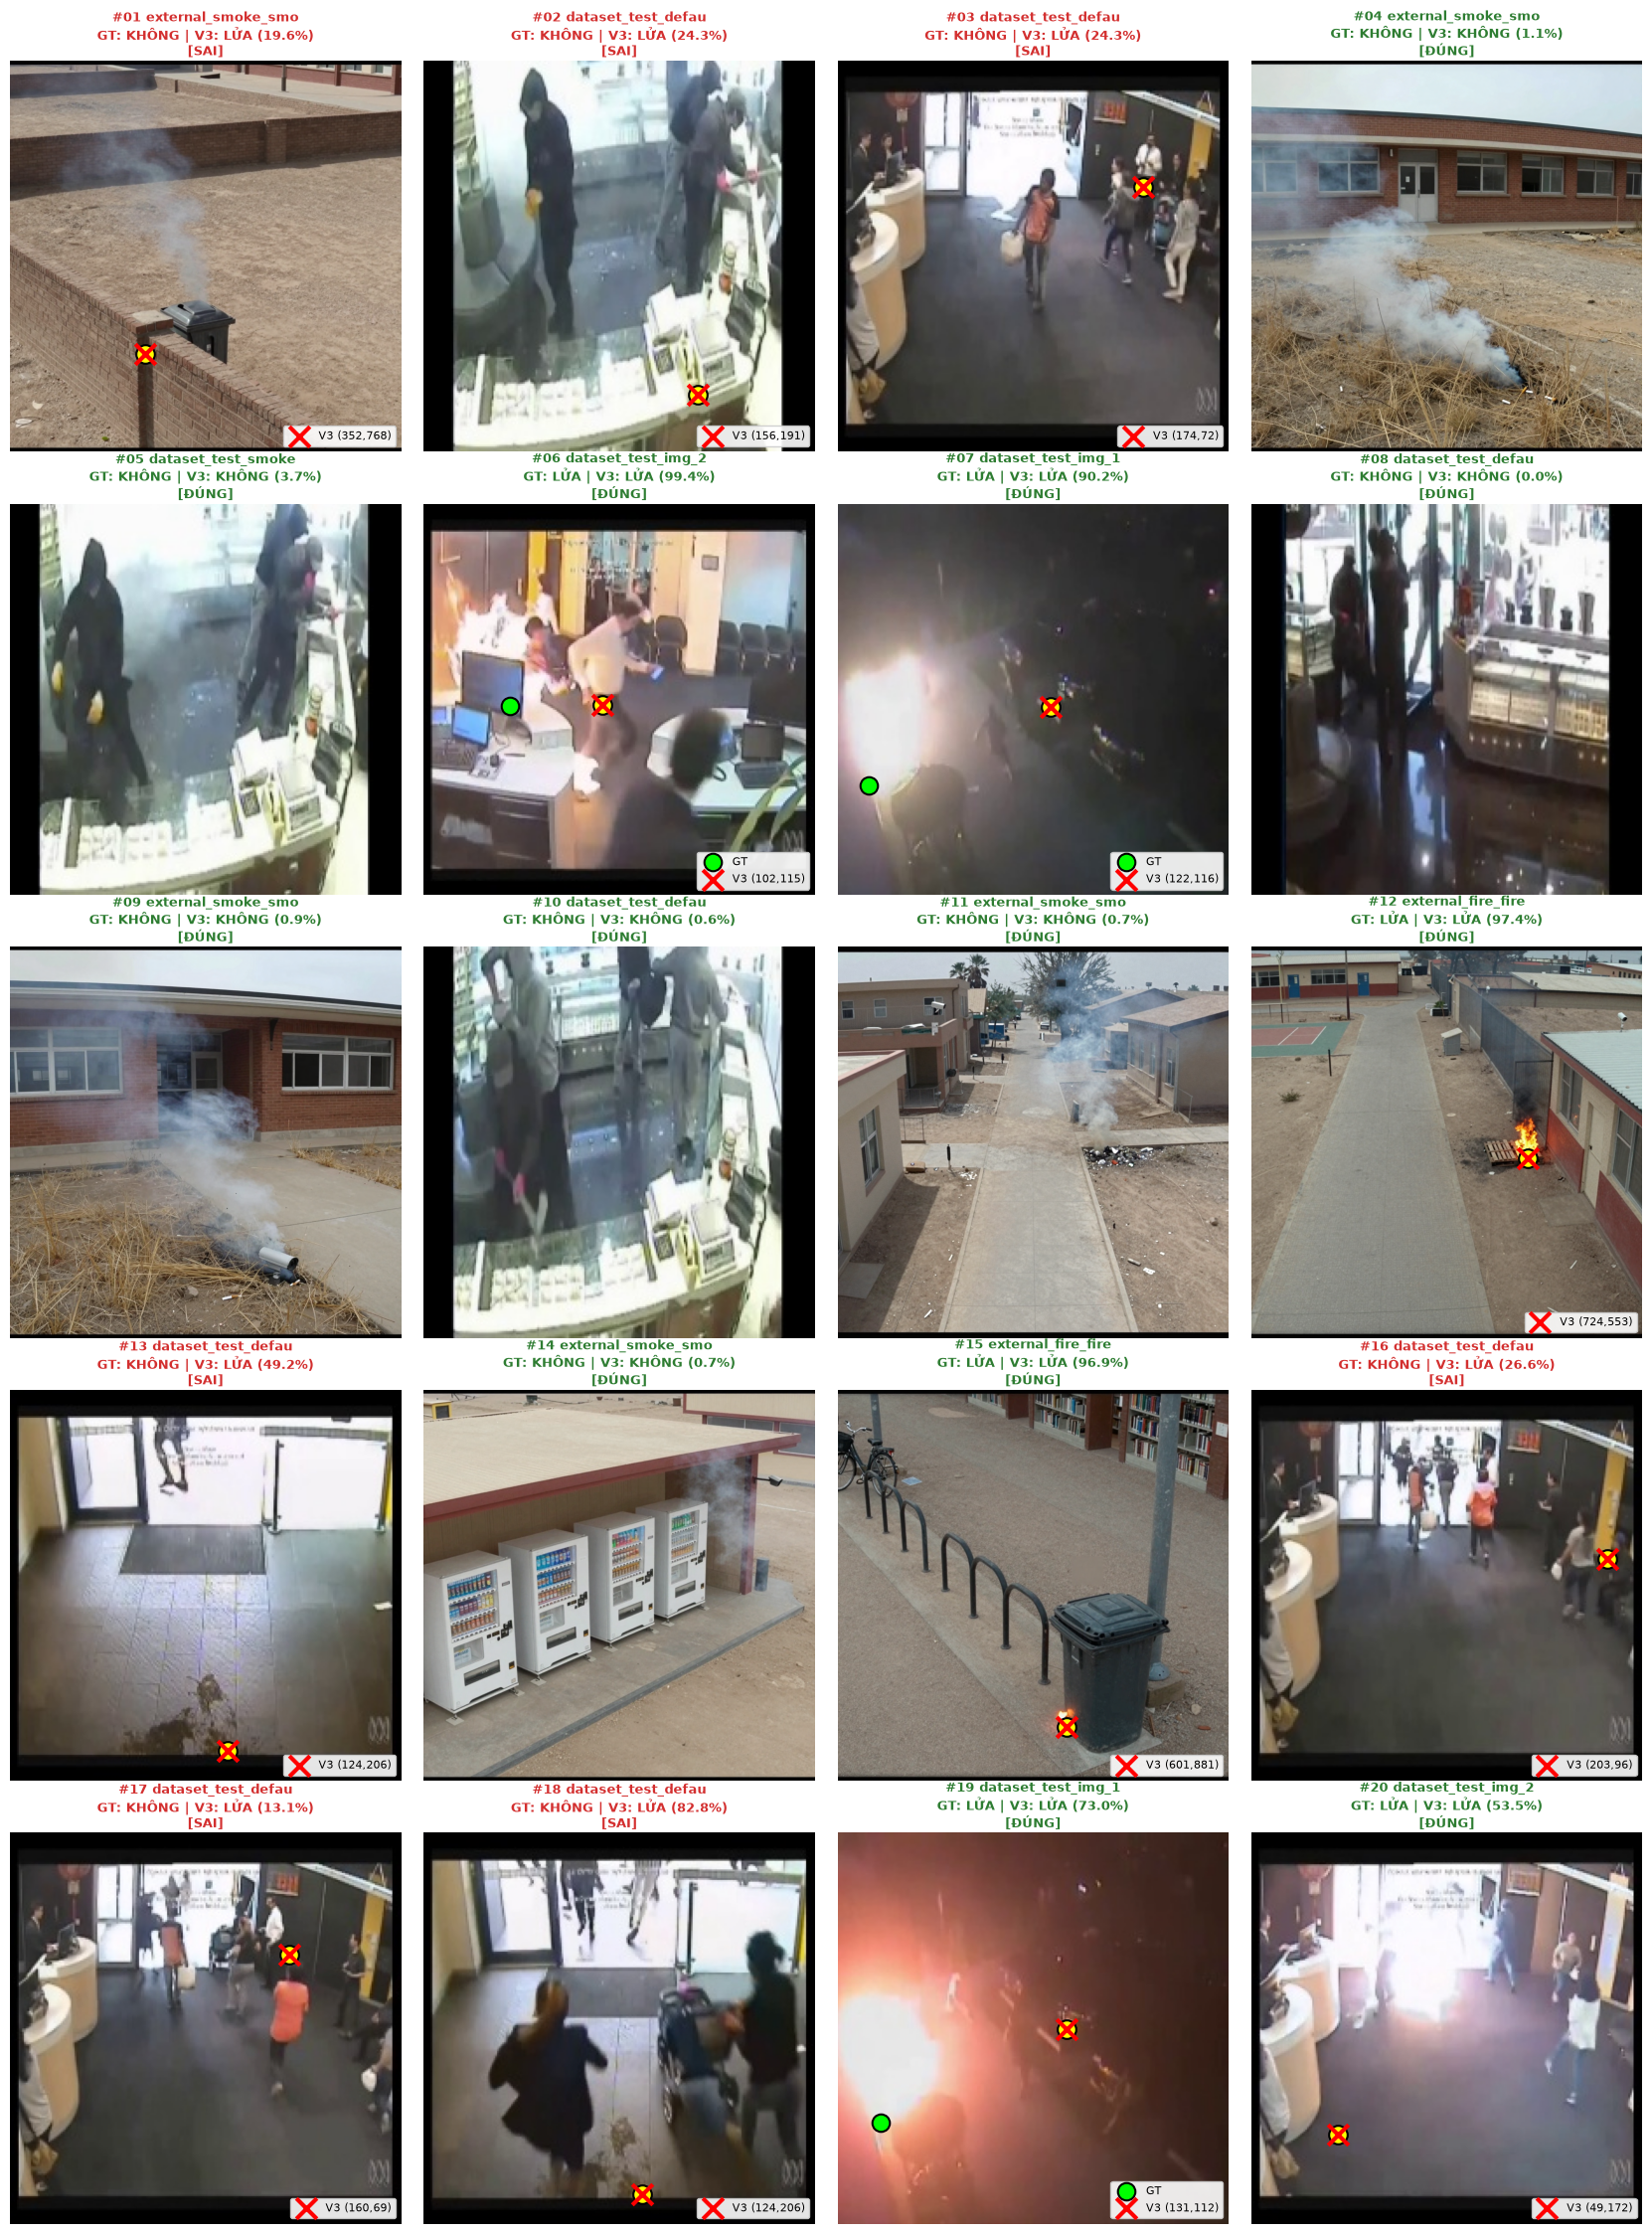

📸 Đã lưu ảnh preview: d:\2D Detection\FireGrounder-V3-main\FireGrounder-V3-main\v3_outputs\eval_fire_samples_last_preview.png


In [7]:
# Cell 7: Trực quan hóa Visual Preview 20 ảnh kiểm thử ngẫu nhiên với Checkpoint Last
rng = random.Random(42)
sample_indices = rng.sample(range(len(dataset_records)), min(20, len(dataset_records)))

cols = 4
rows = (len(sample_indices) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 4.2, rows * 4.5))
axes = np.array(axes).flatten()

BEST_TH = 0.05

for i, s_idx in enumerate(sample_indices):
    ax = axes[i]
    rec = dataset_records[s_idx]
    img = Image.open(rec['path']).convert('RGB')
    w_orig, h_orig = img.size
    
    p_fire = preds_tensor[s_idx, 0].item()
    x_norm = preds_tensor[s_idx, 1].item()
    y_norm = preds_tensor[s_idx, 2].item()
    pred_is_fire = p_fire >= BEST_TH
    gt_is_fire = rec['has_fire'] == 1.0
    
    ax.imshow(img)
    
    # Vẽ Ground Truth nếu có
    if gt_is_fire and rec['coord_gt'] is not None:
        gt_x = rec['coord_gt'][0] * w_orig
        gt_y = rec['coord_gt'][1] * h_orig
        ax.scatter(gt_x, gt_y, c='lime', marker='o', s=160, edgecolors='black', linewidth=1.5, zorder=5, label='GT')
        
    # Vẽ Dự đoán V3 Last
    if pred_is_fire:
        px = x_norm * w_orig
        py = y_norm * h_orig
        ax.scatter(px, py, c='yellow', marker='o', s=180, edgecolors='black', linewidth=1.5, zorder=6)
        ax.scatter(px, py, c='red', marker='x', s=220, linewidth=3.0, zorder=7, label=f'V3 ({px:.0f},{py:.0f})')
        ax.legend(loc='lower right', fontsize=8, facecolor='white', framealpha=0.9)
    
    # Tiêu đề với màu sắc phân biệt đúng/sai
    is_correct = (pred_is_fire == gt_is_fire)
    status_text = 'ĐÚNG' if is_correct else 'SAI'
    title_color = '#2E7D32' if is_correct else '#D32F2F'
    
    title = f"#{i+1:02d} {rec['file'][:18]}\nGT: {'LỬA' if gt_is_fire else 'KHÔNG'} | V3: {'LỬA' if pred_is_fire else 'KHÔNG'} ({p_fire*100:.1f}%)\n[{status_text}]"
    ax.set_title(title, fontsize=9, fontweight='bold', color=title_color, pad=4)
    ax.axis('off')

for j in range(len(sample_indices), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
out_preview = NOTEBOOK_DIR / 'v3_outputs' / 'eval_fire_samples_last_preview.png'
out_preview.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out_preview, dpi=130, bbox_inches='tight')
plt.show()
print(f'📸 Đã lưu ảnh preview: {out_preview}')